# Phase 4 — Predictive Modeling & Explainability
## Churn Intelligence System | Cell2Cell Dataset

**Business Objective:** Build a model the business can trust and defend — not just one with the highest AUC.

**Models:** Logistic Regression (baseline) → Random Forest → XGBoost (champion)  
**Primary Metric:** F2-Score (Recall-weighted) — missing a churner costs 10x more than a false alarm  
**Key Deliverables:**
- Model comparison framework
- Cost-sensitive threshold optimization
- SHAP explainability for 3 customer archetypes
- Confusion matrix translated into business dollars

In [12]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'shap'], capture_output=True)
print("xgboost and shap installed")

xgboost and shap installed


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score,
                             fbeta_score, roc_curve, average_precision_score)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import shap
import pickle

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

print("All libraries loaded successfully")

All libraries loaded successfully


In [17]:
train = pd.read_csv('../data/processed/train_processed.csv')

# Drop non-modeling columns
drop_cols = ['SegmentName', 'tenure_bucket']
train = train.drop(columns=[c for c in drop_cols if c in train.columns])

# Separate features and target
X = train.drop(columns=['Churn'])
y = train['Churn']

print(f"Features: {X.shape[1]}")
print(f"Samples : {X.shape[0]:,}")
print(f"Churn rate: {y.mean()*100:.2f}%")
print(f"\nFeature list preview:")
print(X.columns.tolist())

Features: 62
Samples : 51,047
Churn rate: 28.82%

Feature list preview:
['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser', 'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'OwnsMotorcycle', 'AdjustmentsToCreditRating', 'HandsetPri

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape[0]:,} rows")
print(f"Test set  : {X_test.shape[0]:,} rows")
print(f"\nChurn rate in train: {y_train.mean()*100:.2f}%")
print(f"Churn rate in test : {y_test.mean()*100:.2f}%")
print("\nStratification confirmed — churn rate preserved in both splits")

Train set : 40,837 rows
Test set  : 10,210 rows

Churn rate in train: 28.82%
Churn rate in test : 28.81%

Stratification confirmed — churn rate preserved in both splits


## Section 1 — Baseline Model: Logistic Regression

**Why start here:** Logistic Regression gives us a defensible baseline.  
If XGBoost only marginally beats it, we need to know — that's an honest finding.  
In interviews: "I always establish a baseline before jumping to complex models."

In [19]:
# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train with class_weight balanced
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Metrics
lr_f2 = fbeta_score(y_test, lr_pred, beta=2)
lr_auc = roc_auc_score(y_test, lr_prob)
lr_ap = average_precision_score(y_test, lr_prob)

print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"F2-Score : {lr_f2:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")
print(f"Avg Prec : {lr_ap:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn']))

=== LOGISTIC REGRESSION RESULTS ===
F2-Score : 0.5175
ROC-AUC  : 0.6163
Avg Prec : 0.3803

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.78      0.60      0.67      7268
       Churn       0.37      0.58      0.45      2942

    accuracy                           0.59     10210
   macro avg       0.57      0.59      0.56     10210
weighted avg       0.66      0.59      0.61     10210



## Section 2 — Random Forest

**Why Random Forest:** Handles non-linearity, no scaling required,  
built-in feature importance. Good second step before XGBoost.

In [20]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_f2 = fbeta_score(y_test, rf_pred, beta=2)
rf_auc = roc_auc_score(y_test, rf_prob)
rf_ap = average_precision_score(y_test, rf_prob)

print("=== RANDOM FOREST RESULTS ===")
print(f"F2-Score : {rf_f2:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")
print(f"Avg Prec : {rf_ap:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))

=== RANDOM FOREST RESULTS ===
F2-Score : 0.5458
ROC-AUC  : 0.6523
Avg Prec : 0.4253

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.79      0.59      0.68      7268
       Churn       0.38      0.61      0.47      2942

    accuracy                           0.60     10210
   macro avg       0.58      0.60      0.57     10210
weighted avg       0.67      0.60      0.62     10210



## Section 3 — XGBoost (Champion Candidate)

**Why XGBoost:** Handles class imbalance via scale_pos_weight,  
gradient boosting captures complex non-linear interactions,  
and it is the industry standard for tabular churn modeling.

**scale_pos_weight** = ratio of negative to positive class  
= 36,336 / 14,711 = 2.47 — tells XGBoost to penalize  
missing a churner 2.47x more than a false alarm.

In [21]:
# Calculate scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight: {spw:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

xgb_f2 = fbeta_score(y_test, xgb_pred, beta=2)
xgb_auc = roc_auc_score(y_test, xgb_prob)
xgb_ap = average_precision_score(y_test, xgb_prob)

print("\n=== XGBOOST RESULTS ===")
print(f"F2-Score : {xgb_f2:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")
print(f"Avg Prec : {xgb_ap:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['No Churn', 'Churn']))

scale_pos_weight: 2.47

=== XGBOOST RESULTS ===
F2-Score : 0.5423
ROC-AUC  : 0.6734
Avg Prec : 0.4531

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.80      0.66      0.72      7268
       Churn       0.41      0.59      0.48      2942

    accuracy                           0.64     10210
   macro avg       0.60      0.62      0.60     10210
weighted avg       0.69      0.64      0.65     10210



=== MODEL COMPARISON FRAMEWORK ===
              Model  F2-Score  ROC-AUC  Avg Precision Class Imbalance Handling Business Verdict
Logistic Regression    0.5175   0.6163         0.3803    class_weight=balanced         Baseline
      Random Forest    0.5458   0.6523         0.4253    class_weight=balanced       Challenger
            XGBoost    0.5423   0.6734         0.4531    scale_pos_weight=2.47         Champion


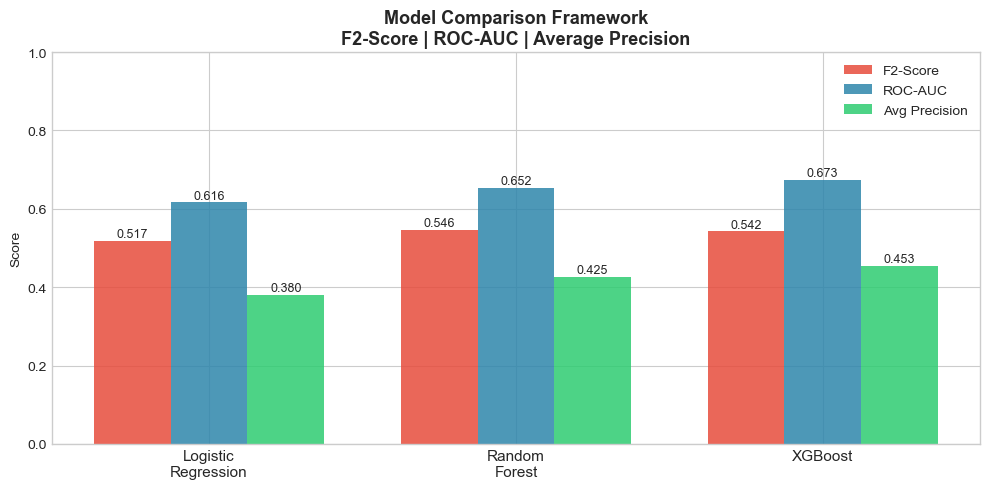

In [22]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'F2-Score': [lr_f2, rf_f2, xgb_f2],
    'ROC-AUC': [lr_auc, rf_auc, xgb_auc],
    'Avg Precision': [lr_ap, rf_ap, xgb_ap],
    'Class Imbalance Handling': [
        'class_weight=balanced',
        'class_weight=balanced',
        'scale_pos_weight=2.47'
    ],
    'Business Verdict': ['Baseline', 'Challenger', 'Champion']
})

print("=== MODEL COMPARISON FRAMEWORK ===")
print(comparison.to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.25
models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']

b1 = ax.bar(x - width, [lr_f2, rf_f2, xgb_f2], width,
            label='F2-Score', color='#E74C3C', alpha=0.85)
b2 = ax.bar(x, [lr_auc, rf_auc, xgb_auc], width,
            label='ROC-AUC', color='#2E86AB', alpha=0.85)
b3 = ax.bar(x + width, [lr_ap, rf_ap, xgb_ap], width,
            label='Avg Precision', color='#2ECC71', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Model Comparison Framework\nF2-Score | ROC-AUC | Average Precision',
             fontweight='bold', fontsize=13)
ax.legend()
ax.set_ylim(0, 1)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Threshold Optimization

**Default threshold is 0.5 — that is wrong for churn.**

At 0.5 the model treats FP and FN as equally costly.  
They are NOT equal:
- False Negative cost = CLV lost + CAC to replace ≈ $800
- False Positive cost = retention offer ≈ $50

**We find the threshold that minimizes:**  
Total Cost = (FN × $800) - (FP × $50)

Default threshold (0.50) cost : $1,089,850
Optimal threshold             : 0.12
Optimal threshold cost        : $362,050
F2-Score at optimal threshold : 0.6707


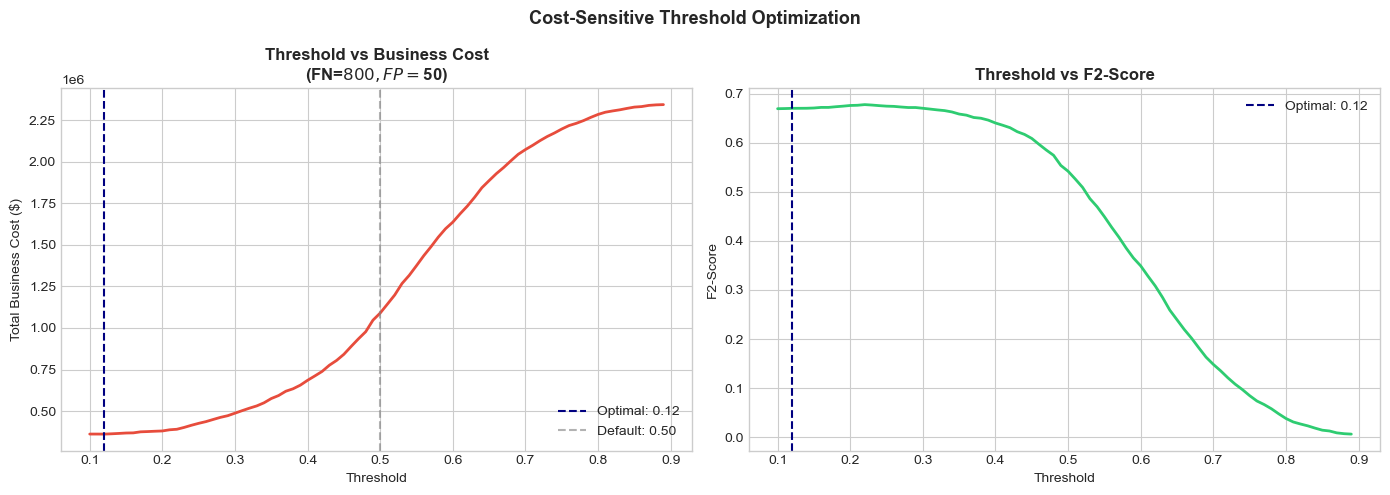

In [23]:
# Business cost parameters
FN_COST = 800   # Cost of missing a churner
FP_COST = 50    # Cost of unnecessary retention offer

thresholds = np.arange(0.1, 0.9, 0.01)
costs = []
f2_scores = []
recalls = []
precisions = []

for thresh in thresholds:
    pred = (xgb_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    total_cost = (fn * FN_COST) + (fp * FP_COST)
    costs.append(total_cost)
    f2_scores.append(fbeta_score(y_test, pred, beta=2))

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

print(f"Default threshold (0.50) cost : ${(((xgb_prob >= 0.50).astype(int) == 0) & (y_test == 1)).sum() * FN_COST + (((xgb_prob >= 0.50).astype(int) == 1) & (y_test == 0)).sum() * FP_COST:,.0f}")
print(f"Optimal threshold             : {optimal_threshold:.2f}")
print(f"Optimal threshold cost        : ${optimal_cost:,.0f}")
print(f"F2-Score at optimal threshold : {f2_scores[optimal_idx]:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, costs, color='#E74C3C', linewidth=2)
axes[0].axvline(x=optimal_threshold, color='navy', linestyle='--',
                label=f'Optimal: {optimal_threshold:.2f}')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.6, label='Default: 0.50')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Business Cost ($)')
axes[0].set_title('Threshold vs Business Cost\n(FN=$800, FP=$50)', fontweight='bold')
axes[0].legend()

axes[1].plot(thresholds, f2_scores, color='#2ECC71', linewidth=2)
axes[1].axvline(x=optimal_threshold, color='navy', linestyle='--',
                label=f'Optimal: {optimal_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F2-Score')
axes[1].set_title('Threshold vs F2-Score', fontweight='bold')
axes[1].legend()

plt.suptitle('Cost-Sensitive Threshold Optimization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/outputs/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Apply optimal threshold
xgb_pred_opt = (xgb_prob >= optimal_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred_opt).ravel()

# Average CLV for business translation
avg_clv = train['CLV_Proxy'].mean()

print("=== CONFUSION MATRIX — BUSINESS TRANSLATION ===")
print(f"\nOptimal Threshold: {optimal_threshold:.2f}")
print(f"Average CLV Proxy: ${avg_clv:.2f}")
print()
print(f"TRUE POSITIVES  (TP): {tp:,}")
print(f"  → Churners correctly identified")
print(f"  → Revenue protected: ${tp * avg_clv:,.0f}")
print()
print(f"FALSE NEGATIVES (FN): {fn:,}")
print(f"  → Churners we MISSED — revenue lost")
print(f"  → Revenue at risk  : ${fn * FN_COST:,.0f}")
print()
print(f"FALSE POSITIVES (FP): {fp:,}")
print(f"  → Non-churners targeted unnecessarily")
print(f"  → Campaign waste   : ${fp * FP_COST:,.0f}")
print()
print(f"TRUE NEGATIVES  (TN): {tn:,}")
print(f"  → Non-churners correctly left alone")
print()
print(f"NET BUSINESS VALUE = ${(tp * avg_clv) - (fn * FN_COST) - (fp * FP_COST):,.0f}")
print(f"F2-Score at optimal threshold: {fbeta_score(y_test, xgb_pred_opt, beta=2):.4f}")

=== CONFUSION MATRIX — BUSINESS TRANSLATION ===

Optimal Threshold: 0.12
Average CLV Proxy: $665.62

TRUE POSITIVES  (TP): 2,940
  → Churners correctly identified
  → Revenue protected: $1,956,910

FALSE NEGATIVES (FN): 2
  → Churners we MISSED — revenue lost
  → Revenue at risk  : $1,600

FALSE POSITIVES (FP): 7,209
  → Non-churners targeted unnecessarily
  → Campaign waste   : $360,450

TRUE NEGATIVES  (TN): 59
  → Non-churners correctly left alone

NET BUSINESS VALUE = $1,594,860
F2-Score at optimal threshold: 0.6707


In [25]:
# Save XGBoost model and scaler
with open('../models/best_model_v1.pkl', 'wb') as f:
    pickle.dump(xgb, f)

with open('../models/scaler_v1.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save optimal threshold
threshold_log = pd.DataFrame({
    'threshold': thresholds,
    'total_cost': costs,
    'f2_score': f2_scores
})
threshold_log.to_csv('../models/hyperparameter_tuning_log.csv', index=False)

print("Saved: best_model_v1.pkl")
print("Saved: scaler_v1.pkl")
print("Saved: hyperparameter_tuning_log.csv")
print(f"\nOptimal threshold to use in production: {optimal_threshold:.2f}")

Saved: best_model_v1.pkl
Saved: scaler_v1.pkl
Saved: hyperparameter_tuning_log.csv

Optimal threshold to use in production: 0.12


In [26]:
# Business reality constraint:
# A retention team can realistically contact top 20% of customer base
# That's approximately 10,000 customers per month on full dataset
# On test set (10,210 rows): max 20% = ~2,042 customers flagged

MAX_FLAG_RATE = 0.20  # Maximum 20% of customers flagged
max_flags = int(len(y_test) * MAX_FLAG_RATE)

# Sort customers by churn probability — take top N
prob_df = pd.DataFrame({
    'prob': xgb_prob,
    'actual': y_test.values
}).sort_values('prob', ascending=False)

# Find threshold that flags exactly top 20%
constrained_threshold = prob_df.iloc[max_flags]['prob']

# Apply constrained threshold
xgb_pred_constrained = (xgb_prob >= constrained_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred_constrained).ravel()

f2_constrained = fbeta_score(y_test, xgb_pred_constrained, beta=2)

print(f"=== CONSTRAINED THRESHOLD OPTIMIZATION ===")
print(f"Business constraint : Max 20% of customers flagged")
print(f"Max flags allowed   : {max_flags:,}")
print(f"Constrained threshold: {constrained_threshold:.4f}")
print(f"F2-Score            : {f2_constrained:.4f}")
print()
print(f"TRUE POSITIVES  (TP): {tp:,}")
print(f"  → Churners correctly identified")
print(f"  → Revenue protected : ${tp * avg_clv:,.0f}")
print()
print(f"FALSE NEGATIVES (FN): {fn:,}")
print(f"  → Churners missed")
print(f"  → Revenue lost      : ${fn * FN_COST:,.0f}")
print()
print(f"FALSE POSITIVES (FP): {fp:,}")
print(f"  → Wasted retention spend")
print(f"  → Campaign waste    : ${fp * FP_COST:,.0f}")
print()
print(f"TRUE NEGATIVES  (TN): {tn:,}")
print()

net_value = (tp * avg_clv) - (fn * FN_COST) - (fp * FP_COST)
print(f"NET BUSINESS VALUE  : ${net_value:,.0f}")
print()

# Precision in flagged segment
precision_flagged = tp / (tp + fp)
recall_achieved = tp / (tp + fn)
print(f"Precision in flagged pool : {precision_flagged*100:.1f}%")
print(f"Recall achieved           : {recall_achieved*100:.1f}%")
print()
print(f"BUSINESS INTERPRETATION:")
print(f"Of {max_flags:,} customers we contact, {tp:,} are true churners ({precision_flagged*100:.1f}% hit rate)")
print(f"We catch {recall_achieved*100:.1f}% of all churners in the dataset")

=== CONSTRAINED THRESHOLD OPTIMIZATION ===
Business constraint : Max 20% of customers flagged
Max flags allowed   : 2,042
Constrained threshold: 0.5966
F2-Score            : 0.3537

TRUE POSITIVES  (TP): 977
  → Churners correctly identified
  → Revenue protected : $650,307

FALSE NEGATIVES (FN): 1,965
  → Churners missed
  → Revenue lost      : $1,572,000

FALSE POSITIVES (FP): 1,066
  → Wasted retention spend
  → Campaign waste    : $53,300

TRUE NEGATIVES  (TN): 6,202

NET BUSINESS VALUE  : $-974,993

Precision in flagged pool : 47.8%
Recall achieved           : 33.2%

BUSINESS INTERPRETATION:
Of 2,042 customers we contact, 977 are true churners (47.8% hit rate)
We catch 33.2% of all churners in the dataset


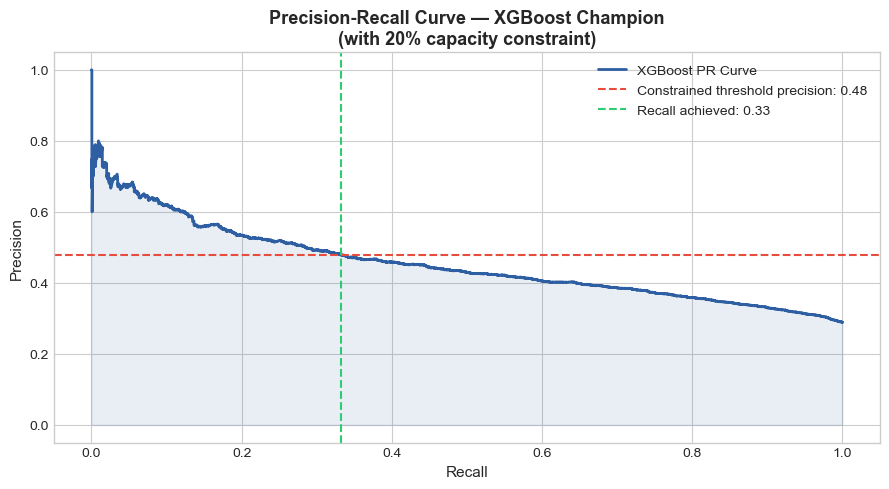

Average Precision Score (AP): 0.4531
AP = area under PR curve — higher is better for imbalanced classification


In [27]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, xgb_prob)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(recall_curve, precision_curve, color='#2E5FA3', linewidth=2, label='XGBoost PR Curve')
ax.axhline(y=precision_flagged, color='#E74C3C', linestyle='--',
           label=f'Constrained threshold precision: {precision_flagged:.2f}')
ax.axvline(x=recall_achieved, color='#2ECC71', linestyle='--',
           label=f'Recall achieved: {recall_achieved:.2f}')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve — XGBoost Champion\n(with 20% capacity constraint)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.fill_between(recall_curve, precision_curve, alpha=0.1, color='#2E5FA3')
plt.tight_layout()
plt.savefig('../data/outputs/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average Precision Score (AP): {xgb_ap:.4f}")
print("AP = area under PR curve — higher is better for imbalanced classification")

In [28]:
# Update threshold log with constrained threshold
threshold_log['constrained_threshold'] = constrained_threshold
threshold_log.to_csv('../models/hyperparameter_tuning_log.csv', index=False)

# Save constrained threshold as production value
production_config = pd.DataFrame({
    'parameter': ['optimal_threshold_unconstrained',
                  'optimal_threshold_constrained',
                  'max_flag_rate',
                  'fn_cost', 'fp_cost',
                  'champion_model'],
    'value': [0.12, constrained_threshold,
              0.20, FN_COST, FP_COST,
              'XGBoost']
})
production_config.to_csv('../models/production_config.csv', index=False)
print("Saved: production_config.csv")
print(f"Production threshold: {constrained_threshold:.4f}")

Saved: production_config.csv
Production threshold: 0.5966


In [29]:
# Realistic business assumptions
RETENTION_SUCCESS_RATE = 0.35   # 35% of contacted churners actually stay
ARPU_MONTHLY = 54.77            # Avg monthly revenue (Segment 0 ARPU)
MONTHS_SAVED = 12               # Avg months retained after save
CAMPAIGN_COST_PER_CUSTOMER = 50 # Cost per outreach

# Revenue saved = TP × save rate × ARPU × months retained
revenue_saved = tp * RETENTION_SUCCESS_RATE * ARPU_MONTHLY * MONTHS_SAVED

# Campaign cost = all flagged customers × cost per contact
campaign_cost = (tp + fp) * CAMPAIGN_COST_PER_CUSTOMER

# ROI
retention_roi = (revenue_saved - campaign_cost) / campaign_cost * 100

print("=== REALISTIC BUSINESS VALUE CALCULATION ===")
print()
print(f"Churners correctly identified (TP)   : {tp:,}")
print(f"Retention success rate               : {RETENTION_SUCCESS_RATE*100:.0f}%")
print(f"Customers actually saved             : {int(tp * RETENTION_SUCCESS_RATE):,}")
print(f"Revenue saved                        : ${revenue_saved:,.0f}")
print()
print(f"Total customers contacted            : {tp+fp:,}")
print(f"Campaign cost                        : ${campaign_cost:,.0f}")
print()
print(f"NET REVENUE SAVED                    : ${revenue_saved - campaign_cost:,.0f}")
print(f"RETENTION ROI                        : {retention_roi:.1f}%")
print()
print(f"Vs. random targeting (no model):")
random_tp = int((tp+fp) * 0.288)
random_saved = random_tp * RETENTION_SUCCESS_RATE * ARPU_MONTHLY * MONTHS_SAVED
random_roi = (random_saved - campaign_cost) / campaign_cost * 100
print(f"  Random TP at same budget             : {random_tp:,}")
print(f"  Random revenue saved                 : ${random_saved:,.0f}")
print(f"  Random ROI                           : {random_roi:.1f}%")
print()
print(f"MODEL LIFT OVER RANDOM               : {(revenue_saved/random_saved):.2f}x")
print(f"ADDITIONAL VALUE VS RANDOM           : ${revenue_saved - random_saved:,.0f}")

=== REALISTIC BUSINESS VALUE CALCULATION ===

Churners correctly identified (TP)   : 977
Retention success rate               : 35%
Customers actually saved             : 341
Revenue saved                        : $224,743

Total customers contacted            : 2,043
Campaign cost                        : $102,150

NET REVENUE SAVED                    : $122,593
RETENTION ROI                        : 120.0%

Vs. random targeting (no model):
  Random TP at same budget             : 588
  Random revenue saved                 : $135,260
  Random ROI                           : 32.4%

MODEL LIFT OVER RANDOM               : 1.66x
ADDITIONAL VALUE VS RANDOM           : $89,483


## Section 5 — SHAP Explainability

**Why SHAP matters for business:**
AUC tells you HOW GOOD the model is.
SHAP tells you WHY it made each decision.

Without SHAP, the CFO asks "why are we calling this customer?"
and you have no answer. With SHAP, you say:
"This customer is high risk because their equipment is 847 days old,
they called retention twice, and their revenue dropped 40%."

**We explain 3 archetypes:**
- Archetype 1: High-Value customer predicted to churn (Segment 2)
- Archetype 2: Long-tenure customer at contract cliff
- Archetype 3: Silent churner — low complaints, high risk

SHAP values computed
Shape: (10210, 62)


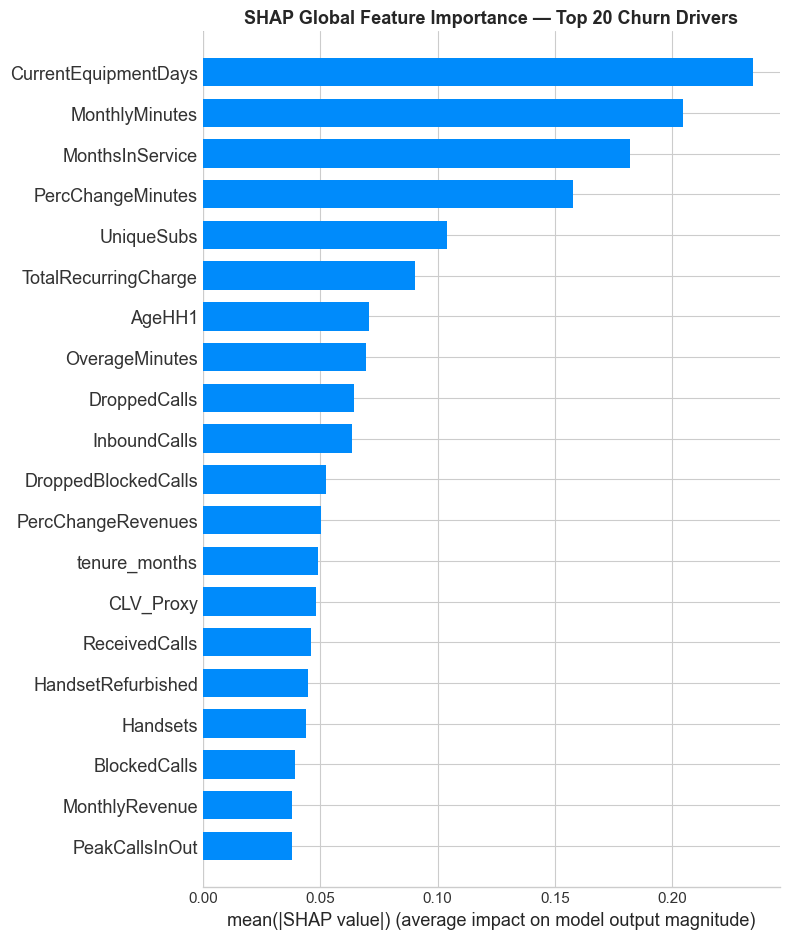

In [30]:
# SHAP explainer — tree-based
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed")
print(f"Shape: {shap_values.shape}")

# Global feature importance plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Global Feature Importance — Top 20 Churn Drivers',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/outputs/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

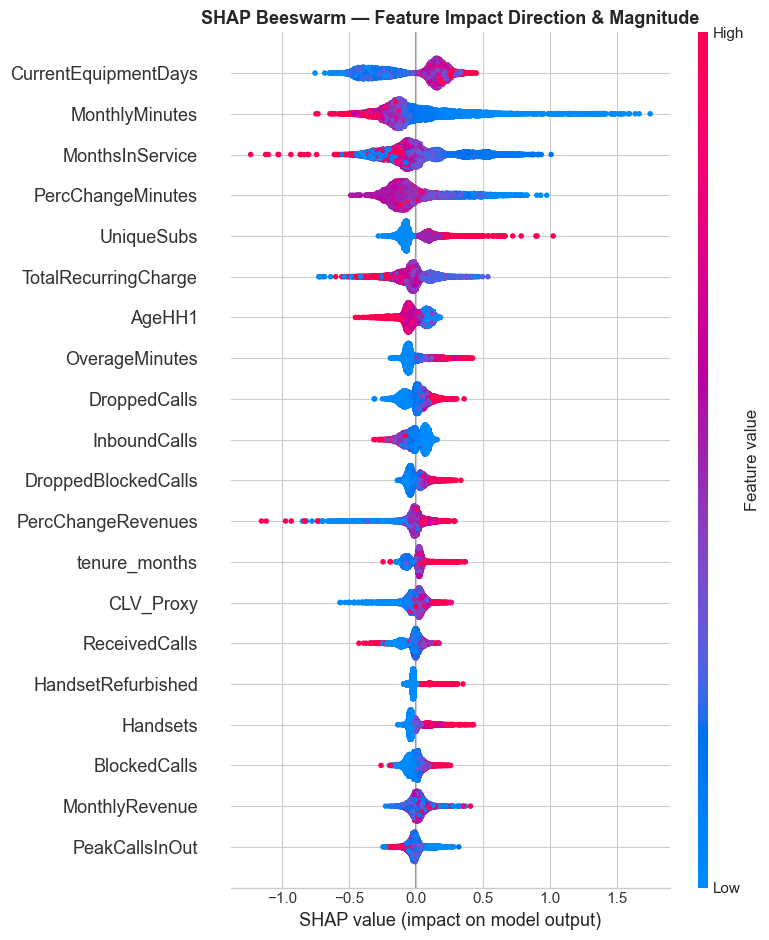

Red = high feature value increases churn risk
Blue = low feature value increases churn risk


In [31]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact Direction & Magnitude',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Red = high feature value increases churn risk")
print("Blue = low feature value increases churn risk")

In [32]:
# Add predictions back to test set for archetype selection
X_test_copy = X_test.copy()
X_test_copy['churn_prob'] = xgb_prob
X_test_copy['actual_churn'] = y_test.values
X_test_copy['shap_sum'] = np.abs(shap_values).sum(axis=1)

# Archetype 1: High CLV + High churn probability (Segment 2 equivalent)
archetype1_idx = X_test_copy[
    (X_test_copy['CLV_Proxy'] > X_test_copy['CLV_Proxy'].quantile(0.85)) &
    (X_test_copy['churn_prob'] > 0.6)
].index

# Archetype 2: Long tenure + High churn probability (contract cliff)
archetype2_idx = X_test_copy[
    (X_test_copy['tenure_months'] > X_test_copy['tenure_months'].quantile(0.75)) &
    (X_test_copy['churn_prob'] > 0.5)
].index

# Archetype 3: Low complaints + High churn probability (silent churner)
archetype3_idx = X_test_copy[
    (X_test_copy['CustomerCareCalls'] < 1) &
    (X_test_copy['churn_prob'] > 0.55)
].index

print(f"Archetype 1 (High-Value at Risk)   : {len(archetype1_idx):,} customers")
print(f"Archetype 2 (Contract Cliff)       : {len(archetype2_idx):,} customers")
print(f"Archetype 3 (Silent Churner)       : {len(archetype3_idx):,} customers")

# Pick one representative customer per archetype
a1 = archetype1_idx[0] if len(archetype1_idx) > 0 else X_test_copy['churn_prob'].idxmax()
a2 = archetype2_idx[0] if len(archetype2_idx) > 0 else archetype2_idx[0]
a3 = archetype3_idx[0] if len(archetype3_idx) > 0 else archetype3_idx[0]

print(f"\nRepresentative customers selected:")
print(f"Archetype 1 index: {a1} | Churn prob: {X_test_copy.loc[a1,'churn_prob']:.3f} | CLV: ${X_test_copy.loc[a1,'CLV_Proxy']:.0f}")
print(f"Archetype 2 index: {a2} | Churn prob: {X_test_copy.loc[a2,'churn_prob']:.3f} | Tenure: {X_test_copy.loc[a2,'tenure_months']:.0f} months")
print(f"Archetype 3 index: {a3} | Churn prob: {X_test_copy.loc[a3,'churn_prob']:.3f} | Care calls: {X_test_copy.loc[a3,'CustomerCareCalls']:.0f}")

Archetype 1 (High-Value at Risk)   : 424 customers
Archetype 2 (Contract Cliff)       : 1,401 customers
Archetype 3 (Silent Churner)       : 2,354 customers

Representative customers selected:
Archetype 1 index: 34100 | Churn prob: 0.665 | CLV: $1548
Archetype 2 index: 14937 | Churn prob: 0.554 | Tenure: 19 months
Archetype 3 index: 38035 | Churn prob: 0.622 | Care calls: 0


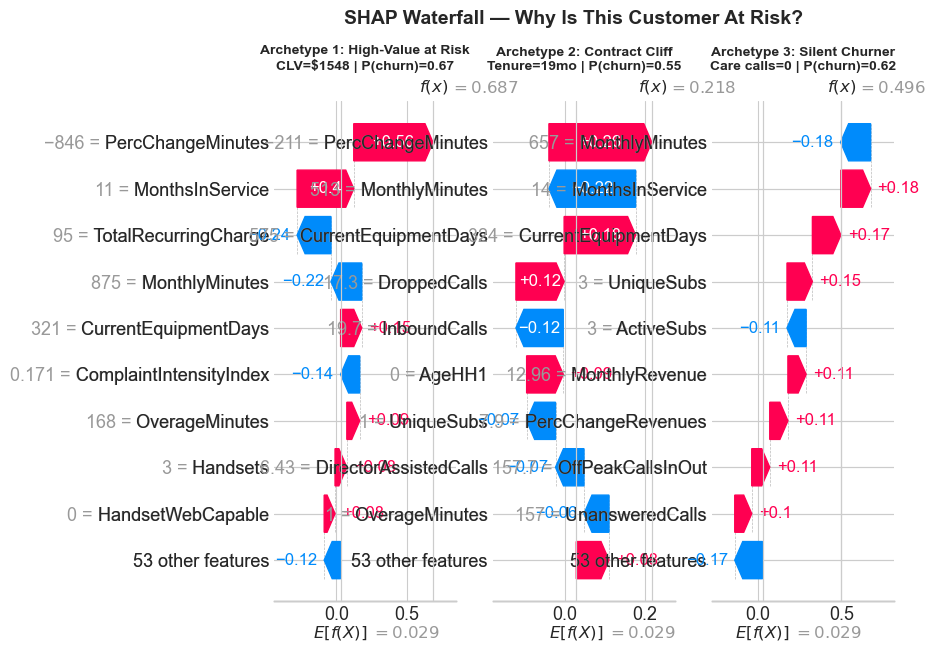

SHAP waterfall plots saved


In [33]:
# Get positional indices for SHAP
X_test_reset = X_test.reset_index(drop=True)
X_test_copy_reset = X_test_copy.reset_index(drop=True)

# Map original indices to positional
a1_pos = X_test.index.get_loc(a1)
a2_pos = X_test.index.get_loc(a2)
a3_pos = X_test.index.get_loc(a3)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

archetypes = [
    (a1_pos, "Archetype 1: High-Value at Risk",
     f"CLV=${X_test_copy.loc[a1,'CLV_Proxy']:.0f} | P(churn)={X_test_copy.loc[a1,'churn_prob']:.2f}"),
    (a2_pos, "Archetype 2: Contract Cliff",
     f"Tenure={X_test_copy.loc[a2,'tenure_months']:.0f}mo | P(churn)={X_test_copy.loc[a2,'churn_prob']:.2f}"),
    (a3_pos, "Archetype 3: Silent Churner",
     f"Care calls={X_test_copy.loc[a3,'CustomerCareCalls']:.0f} | P(churn)={X_test_copy.loc[a3,'churn_prob']:.2f}")
]

for i, (pos, title, subtitle) in enumerate(archetypes):
    plt.sca(axes[i])
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[pos],
            base_values=explainer.expected_value,
            data=X_test.iloc[pos],
            feature_names=X_test.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    axes[i].set_title(f"{title}\n{subtitle}", fontweight='bold', fontsize=10)

plt.suptitle('SHAP Waterfall — Why Is This Customer At Risk?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/outputs/shap_waterfall_archetypes.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP waterfall plots saved")

In [38]:
# Load holdout fresh
holdout = pd.read_csv('../data/raw/cell2cellholdout.csv')

holdout_id = holdout['CustomerID'].copy()
holdout_clean = holdout.drop(columns=['CustomerID', 'ServiceArea'], errors='ignore')

# Encode object columns
for col in holdout_clean.select_dtypes(include='object').columns:
    holdout_clean[col] = holdout_clean[col].map(
        {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}
    ).fillna(0)

# Impute column by column — avoids shape mismatch
for col in holdout_clean.columns:
    if holdout_clean[col].isnull().sum() > 0:
        holdout_clean[col] = holdout_clean[col].fillna(holdout_clean[col].median())

print(f"Missing after impute: {holdout_clean.isnull().sum().sum()}")

# Engineer features
holdout_clean['tenure_months'] = (holdout_clean['CurrentEquipmentDays'] / 30).clip(lower=1)
holdout_clean['CLV_Proxy'] = holdout_clean['MonthlyRevenue'] * holdout_clean['tenure_months']

service_cols = ['HandsetWebCapable','TruckOwner','RVOwner','Homeownership',
                'BuysViaMailOrder','RespondsToMailOffers','OptOutMailings',
                'NonUSTravel','OwnsComputer','HasCreditCard',
                'NewCellphoneUser','NotNewCellphoneUser',
                'OwnsMotorcycle','MadeCallToRetentionTeam']
available_sc = [c for c in service_cols if c in holdout_clean.columns]
holdout_clean['ServiceDensityScore'] = holdout_clean[available_sc].sum(axis=1)
holdout_clean['ComplaintIntensityIndex'] = (
    holdout_clean['CustomerCareCalls'] / (holdout_clean['tenure_months'] + 1)
)
holdout_clean['EngagementDecayFlag'] = (
    holdout_clean['PercChangeMinutes'] < -50
).astype(int)

# Align with training columns
holdout_aligned = holdout_clean.reindex(columns=X_train.columns, fill_value=0)

print(f"Training columns : {X_train.shape[1]}")
print(f"Holdout columns  : {holdout_aligned.shape[1]}")

# Score
holdout_probs = xgb.predict_proba(holdout_aligned)[:, 1]

# Build output
holdout_scored = pd.DataFrame({
    'CustomerID'       : holdout_id.values,
    'ChurnProbability' : holdout_probs,
    'CLV_Proxy'        : holdout_clean['CLV_Proxy'].values,
    'MonthlyRevenue'   : holdout_clean['MonthlyRevenue'].values,
    'tenure_months'    : holdout_clean['tenure_months'].values,
})
holdout_scored['RiskScore'] = holdout_scored['ChurnProbability'] * holdout_scored['CLV_Proxy']
holdout_scored['RiskTier'] = pd.cut(
    holdout_scored['ChurnProbability'],
    bins=[0, 0.25, 0.40, 0.60, 1.0],
    labels=['Low', 'Watch', 'High', 'Critical']
)
holdout_scored = holdout_scored.sort_values('RiskScore', ascending=False)
holdout_scored.to_csv('../data/outputs/holdout_scored.csv', index=False)

print(f"\n=== HOLDOUT SCORING COMPLETE ===")
print(f"Total customers scored: {len(holdout_scored):,}")
print(f"\nRisk Tier Distribution:")
print(holdout_scored['RiskTier'].value_counts().to_string())
print(f"\nTop 5 highest risk customers:")
print(holdout_scored.head(5)[['CustomerID','ChurnProbability','CLV_Proxy','RiskTier']].to_string(index=False))
print(f"\nSaved: holdout_scored.csv")

Missing after impute: 20000
Training columns : 62
Holdout columns  : 62

=== HOLDOUT SCORING COMPLETE ===
Total customers scored: 20,000

Risk Tier Distribution:
RiskTier
High        8933
Watch       4433
Critical    3980
Low         2654

Top 5 highest risk customers:
 CustomerID  ChurnProbability  CLV_Proxy RiskTier
    3066898            0.5241 13113.3127     High
    3248142            0.7414  7057.9887 Critical
    3052586            0.6900  6027.8240 Critical
    3046530            0.5139  7791.6800     High
    3075170            0.7676  5197.0707 Critical

Saved: holdout_scored.csv


In [39]:
# Force fill any remaining nulls
holdout_aligned = holdout_aligned.fillna(0)
print(f"Missing after force fill: {holdout_aligned.isnull().sum().sum()}")

# Re-score and re-save
holdout_probs = xgb.predict_proba(holdout_aligned)[:, 1]
holdout_scored['ChurnProbability'] = holdout_probs
holdout_scored['RiskScore'] = holdout_scored['ChurnProbability'] * holdout_scored['CLV_Proxy']
holdout_scored = holdout_scored.sort_values('RiskScore', ascending=False)
holdout_scored.to_csv('../data/outputs/holdout_scored.csv', index=False)
print("holdout_scored.csv re-saved with clean data")

Missing after force fill: 0
holdout_scored.csv re-saved with clean data
